# Using Flax linen networks

The networks implemented in `sbijax.nn` are [Haiku](https://github.com/google-deepmind/dm-haiku) transforms, but 
they are easily exchanged using [Flax's](https://flax-linen.readthedocs.io/en/latest/) `linen` API. Both only require calling two functions: `init` and `apply`, so any neural network library works as long as those two functions have the signatures the method expects.

This notebook shows how to plug `linen` modules into `sbijax`, first for a classifier-based estimator (NRE), then for
a density-based estimator (NPE).

In [1]:
from collections.abc import Sequence
from typing import NamedTuple

import flax.linen as nn
import jax
from jax import numpy as jnp, random as jr
from tensorflow_probability.substrates.jax import distributions as tfd

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
def plot_posterior_hist(samples, bins=40):
  draws = [
    samples["mean"][..., 0].reshape(-1),
    samples["mean"][..., 1].reshape(-1),
    samples["variance"][..., 0].reshape(-1),
  ]
  fig, axes = plt.subplots(1, 3, figsize=(9, 3))
  for ax, name, dist, x in zip(
    axes, ["mean[0]", "mean[1]", "variance"], exact_dists, draws
  ):
    ax.hist(x, bins=bins, density=True, alpha=0.5, color="#700e01", label="samples")
    grid = jnp.linspace(x.min(), x.max(), 200)
    ax.plot(grid, dist.prob(grid), color="black", label="exact")
    ax.set_title(name)
  axes[0].legend()
  fig.tight_layout()
  return fig

## What a method calls on a network

Every method in `sbijax` builds its `init_fn` around a single call to `network.init` and computes its loss and its samples through calls to `network.apply`. The two families differ in what those calls look like.

A classifier, as used by `nre`, is called without a random key, because `sbijax.nn.make_mlp` wraps its Haiku transform in `hk.without_apply_rng`:

```python
network.init(rng_key, inputs)
network.apply(params, inputs, is_training=False)
```

A conditional density estimator, as used by `npe`, `nle` and all methods in this family, is called with a random key in second position and a `method` keyword selecting which part of the network to run:

```python
network.init(rng_key, method="log_prob", y=theta, x=y)
network.apply(params, None, method="log_prob", y=theta, x=y)
network.apply(params, rng_key, method="sample", sample_shape=(n,), x=y)
```

`Linen` already matches most of this. Its `init` and `apply` both accept `method` as a string naming a method on the module, and `params` is opaque to `sbijax` (it goes straight into `optax`), so a Linen variables dict travels through unchanged. The one difference is the random key: Linen takes it as an `rngs` keyword mapping stream names to keys rather than as a positional argument. Bridging that is a five-line wrapper.

## Model definition

We use the Normal-Inverse-Gamma model from the "Getting started" notebook. It is
conjugate, so both posteriors below can be compared against the analytical one:

\begin{align}
\sigma^2 &\sim \text{InvGamma}(a_0, b_0)\\
\mu \mid \sigma^2 &\sim \mathcal{N}_2\left(0, \frac{\sigma^2}{\kappa_0} I\right)\\
y \mid \mu, \sigma^2 & \sim \mathcal{N}_2(\mu, \sigma^2 I)
\end{align}

In [3]:
a0, b0, kappa0 = 3.0, 2.0, 1.0


def prior_fn():
  prior = tfd.JointDistributionNamed(
    dict(
      variance=tfd.InverseGamma(
        concentration=a0 * jnp.ones(1), scale=b0 * jnp.ones(1)
      ),
      mean=lambda variance: tfd.Normal(jnp.zeros(2), jnp.sqrt(variance / kappa0)),
    ),
    batch_ndims=0,
  )
  return prior


def simulator_fn(seed: jr.PRNGKey, theta: dict[str, jax.Array]):
  p = tfd.Normal(jnp.zeros_like(theta["mean"]), jnp.sqrt(theta["variance"]))
  y = theta["mean"] + p.sample(seed=seed)
  return y

In [4]:
from sbijax import sample, simulate, train
from sbijax.mcmc import make_sampler, nuts

prior = prior_fn()
data = simulate(jr.key(1), prior, simulator_fn, n=10_000)
y_obs = jnp.array([-1.0, 1.0])

Let's define the true, analytical posteriors for comparison.

In [5]:
kappa1 = kappa0 + 1
mu1 = (kappa0 * jnp.zeros(2) + y_obs) / kappa1
a1 = a0 + 1
b1 = b0 + 0.5 * (kappa0 / kappa1) * jnp.sum(y_obs**2)

variance_dist = tfd.InverseGamma(concentration=a1, scale=b1)
mean_dist = tfd.StudentT(df=2 * a1, loc=mu1, scale=jnp.sqrt(b1 / (a1 * kappa1)))
exact_dists = [mean_dist[0], mean_dist[1], variance_dist]

## A classifier for neural ratio estimation

`nre` needs a network that maps the inputs to a single logit. In `linen` that is an ordinary module with a `__call__` method.

In [6]:
class MLP(nn.Module):
  hidden_sizes: Sequence[int] = (64, 64)

  @nn.compact
  def __call__(self, inputs):
    hidden = inputs
    for size in self.hidden_sizes:
      hidden = jax.nn.gelu(nn.Dense(size)(hidden))
    return nn.Dense(1)(hidden)

The wrapper below is the entire adaptation. Its `init` forwards to Linen untouched. Its `apply` takes the input array in the position where `nre` puts it and drops the `is_training` keyword, which Haiku modules read but this Linen module has no use for.

In [7]:
class AsClassifier(NamedTuple):
  module: nn.Module

  def init(self, rng_key, inputs):
    return self.module.init(rng_key, inputs)

  def apply(self, params, inputs, **kwargs):
    return self.module.apply(params, inputs)

In [8]:
from sbijax import nre

ratio_model = nre(AsClassifier(MLP()))
ratio_params, ratio_info = train(jr.key(2), ratio_model, data)

  4%|█▊                                                | 35/1000 [00:21<10:03,  1.60it/s]


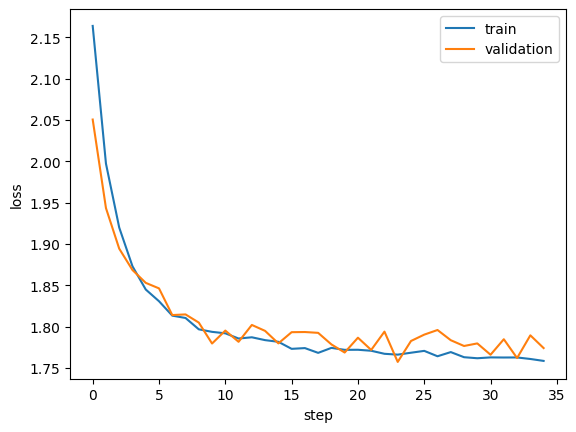

In [9]:
plt.plot(ratio_info.losses[1:, 0], label="train")
plt.plot(ratio_info.losses[1:, 1], label="validation")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

A ratio estimator learns a prior-independent object, so the posterior is only formed at sampling time, when the prior travels in with the sampler.

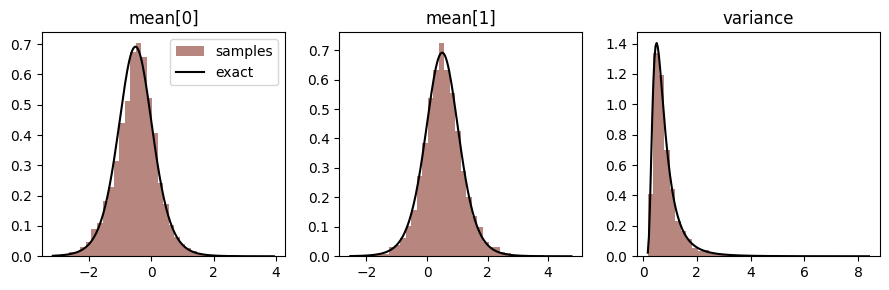

In [10]:
ratio_samples, _ = sample(
  jr.key(3),
  ratio_model,
  ratio_params,
  y_obs,
  sampler=make_sampler(nuts, prior=prior),
  n_chains=4,
  n_samples=2_000,
  n_warmup=1_000,
)
_ = plot_posterior_hist(ratio_samples)

## A density estimator for neural posterior estimation

`npe` wants a network with a `log_prob` method for training and a `sample` method for drawing from the fitted posterior. We write a mixture density network, the Linen counterpart of `sbijax.nn.make_mdn`.

Because two methods share the same parameters, the layers are created in `setup` rather than with `@nn.compact`, and both methods read them from `self`. `sample` draws its randomness from `self.make_rng("sample")`, which is the stream the wrapper below will feed.

In [11]:
class MixtureDensityNetwork(nn.Module):
  n_dimension: int
  n_components: int
  hidden_sizes: Sequence[int] = (64, 64)

  def setup(self):
    self.hidden = [nn.Dense(size) for size in self.hidden_sizes]
    self.logits = nn.Dense(self.n_components)
    self.mu_sigma = nn.Dense(self.n_components * self.n_dimension * 2)

  def _mixture(self, x):
    hidden = x
    for layer in self.hidden:
      hidden = jax.nn.relu(layer(hidden))
    n = x.shape[0]
    mu, sigma = jnp.split(self.mu_sigma(hidden), 2, axis=-1)
    return tfd.MixtureSameFamily(
      tfd.Categorical(logits=self.logits(hidden)),
      tfd.MultivariateNormalDiag(
        mu.reshape(n, self.n_components, self.n_dimension),
        jnp.exp(sigma.reshape(n, self.n_components, self.n_dimension)),
      ),
    )

  def log_prob(self, y, x):
    return self._mixture(x).log_prob(y)

  def sample(self, x, sample_shape=()):
    return self._mixture(x).sample(seed=self.make_rng("sample"))

`sample` ignores `sample_shape` for the same reason `make_mdn` does: `npe` tiles the observation to `n_samples` rows before calling, so the batch axis already carries the draws.

The wrapper moves the random key from the positional slot into an `rngs` dictionary. `npe` passes `None` there while computing the training loss, since `log_prob` needs no randomness, and Linen accepts `rngs=None` for exactly that case.

In [12]:
class AsDensityEstimator(NamedTuple):
  module: nn.Module

  def init(self, rng_key, method, **kwargs):
    return self.module.init(rng_key, method=method, **kwargs)

  def apply(self, params, rng_key, method, **kwargs):
    rngs = None if rng_key is None else {"sample": rng_key}
    return self.module.apply(params, method=method, rngs=rngs, **kwargs)

The network models the posterior over the flattened parameter vector, which has three entries here: two for `mean` and one for `scale`.

In [13]:
from sbijax import npe

n_dim_theta = len(jax.flatten_util.ravel_pytree(prior.sample(seed=jr.key(1)))[0])
network = MixtureDensityNetwork(n_dimension=n_dim_theta, n_components=5)

posterior_model = npe(AsDensityEstimator(network))
posterior_params, posterior_info = train(jr.key(2), posterior_model, data)

  5%|██▎                                               | 47/1000 [00:24<08:24,  1.89it/s]


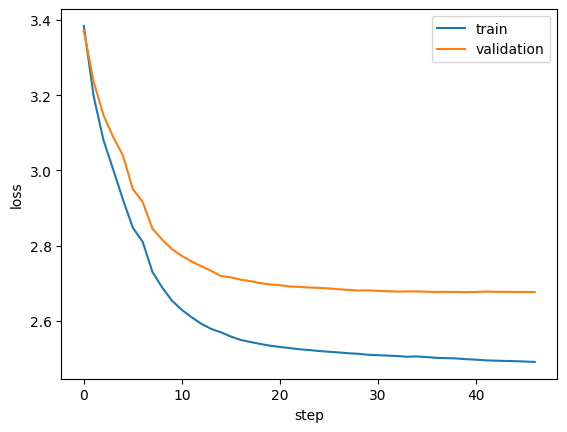

In [14]:
plt.plot(posterior_info.losses[1:, 0], label="train")
plt.plot(posterior_info.losses[1:, 1], label="validation")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.show()

A posterior estimator draws directly from the fitted network, so no sampler is needed. Passing `prior=` reshapes the flat draws back into the prior's pytree structure.

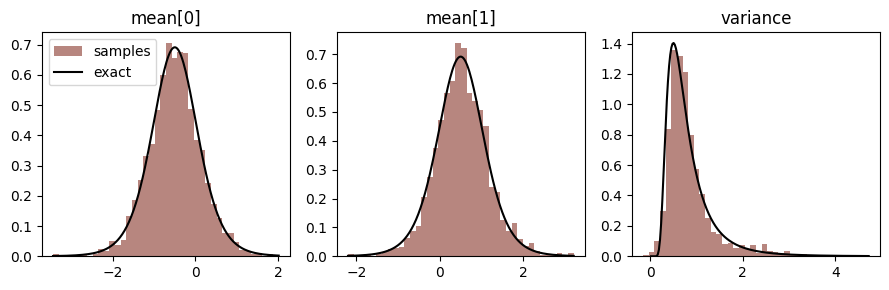

In [15]:
posterior_samples, _ = sample(
  jr.key(3),
  posterior_model,
  posterior_params,
  y_obs,
  prior=prior,
  n_samples=2_000,
)
_ = plot_posterior_hist(posterior_samples)

## Summary

To use a network from another library, give `sbijax` an object with `init` and `apply` matching the calls listed at the top of this notebook. For `linen` the adaptation comes down to where the random key goes. The same recipe applies to `nle`, `snle` and the summary networks, which reuse the density estimator and classifier conventions shown here.

## Session info

In [16]:
import session_info

session_info.show(html=False)

-----
flax                        0.12.9
jax                         0.11.1
jaxlib                      0.11.1
matplotlib                  3.10.8
sbijax                      0.4.0
session_info                v1.0.1
tensorflow_probability      0.26.0-dev20260318
-----
IPython             9.11.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.6
notebook            7.5.5
-----
Python 3.12.10 (main, May 30 2025, 05:53:56) [Clang 20.1.4 ]
macOS-26.2-arm64-arm-64bit
-----
Session information updated at 2026-09-13 00:21
